<a href="https://colab.research.google.com/github/cantika-alff/2025_PBO_TI1B/blob/main/UTS_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

# Membaca data
df = pd.read_csv("airbnb.csv")

# Menampilkan info data
print(df.info())

# Menampilkan missing value\print(df.isnull().sum())
# Statistik dasar
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

# Pandas

## Read


In [2]:
import pandas as pd
df = pd.read_csv("airbnb.csv")
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


## Series

In [3]:
# Mengakses satu kolom sebagai Series
price_series = df['price']
print(price_series.head())

0    149
1    225
2    150
3     89
4     80
Name: price, dtype: int64


## DataFrame

In [9]:
# Menampilkan kolom 'name', 'price', dan 'room_type'
df_selection = df[['name', 'price', 'room_type']]
print(df_selection.head())

                                               name  price        room_type
0                Clean & quiet apt home by the park    149     Private room
1                             Skylit Midtown Castle    225  Entire home/apt
2               THE VILLAGE OF HARLEM....NEW YORK !    150     Private room
3                   Cozy Entire Floor of Brownstone     89  Entire home/apt
4  Entire Apt: Spacious Studio/Loft by central park     80  Entire home/apt


## Manipulation

In [18]:
# Menambah kolom baru: harga per review
df['price_per_review'] = df['price'] / (df['number_of_reviews'] + 1)

# Mengisi NaN pada reviews_per_month dengan 0
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)

# Filter listing dengan harga di bawah 100 dan tersedia sepanjang tahun
cheap_available = df[(df['price'] < 100) & (df['availability_365'] > 0)]
print(cheap_available.head())

      id                                              name  host_id  \
3   3831                   Cozy Entire Floor of Brownstone     4869   
7   5178                  Large Furnished Room Near B'way      8967   
11  5441                   Central Manhattan/near Broadway     7989   
12  5803    Lovely Room 1, Garden, Best Area, Legal rental     9744   
13  6021  Wonderful Guest Bedroom in Manhattan for SINGLES    11528   

      host_name neighbourhood_group    neighbourhood  latitude  longitude  \
3   LisaRoxanne            Brooklyn     Clinton Hill  40.68514  -73.95976   
7      Shunichi           Manhattan   Hell's Kitchen  40.76489  -73.98493   
11         Kate           Manhattan   Hell's Kitchen  40.76076  -73.98867   
12       Laurie            Brooklyn      South Slope  40.66829  -73.98779   
13      Claudio           Manhattan  Upper West Side  40.79826  -73.96113   

          room_type  price  minimum_nights  number_of_reviews last_review  \
3   Entire home/apt     89       

## Plotting

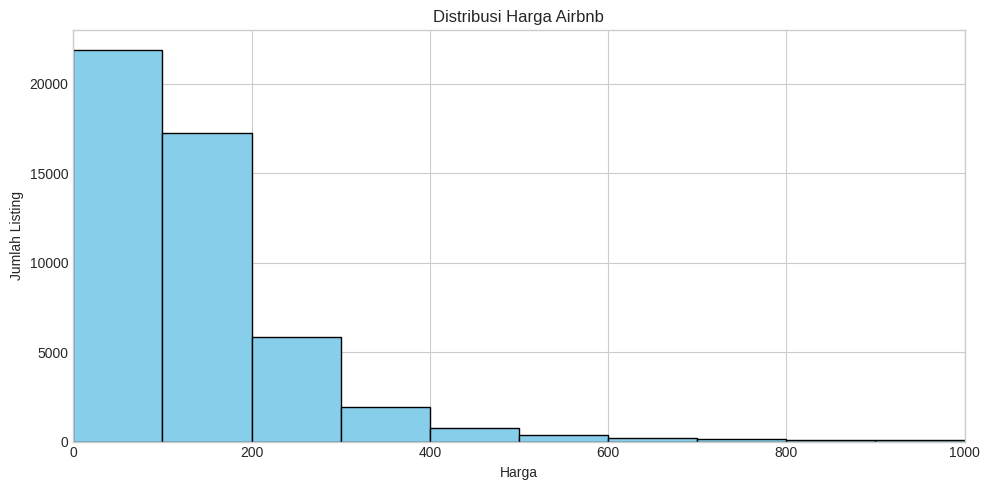

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.hist(df['price'], bins=100, color='skyblue', edgecolor='black')
plt.xlim(0, 1000)
plt.title('Distribusi Harga Airbnb')
plt.xlabel('Harga')
plt.ylabel('Jumlah Listing')
plt.grid(True)
plt.tight_layout()
plt.show()


matlobitip

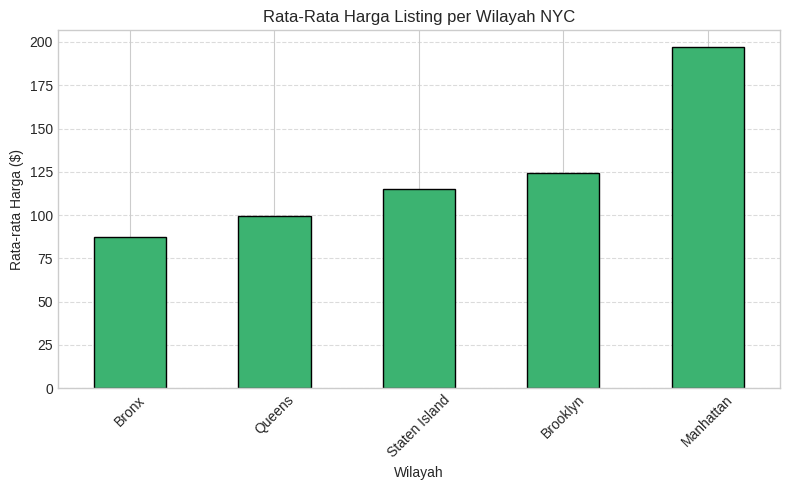

In [21]:
import matplotlib.pyplot as plt

# Rata-rata harga berdasarkan wilayah
avg_price_per_area = df.groupby('neighbourhood_group')['price'].mean().sort_values()

# Plot bar chart
plt.figure(figsize=(8, 5))
avg_price_per_area.plot(kind='bar', color='mediumseagreen', edgecolor='black')

plt.title('Rata-Rata Harga Listing per Wilayah NYC')
plt.xlabel('Wilayah')
plt.ylabel('Rata-rata Harga ($)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


custom


Rata-rata Harga per Wilayah:

neighbourhood_group
Bronx             87.50
Queens            99.52
Staten Island    114.81
Brooklyn         124.38
Manhattan        196.88
Name: price, dtype: float64

Jumlah Listing per Jenis Kamar:

room_type
Entire home/apt    25409
Private room       22326
Shared room         1160
Name: count, dtype: int64


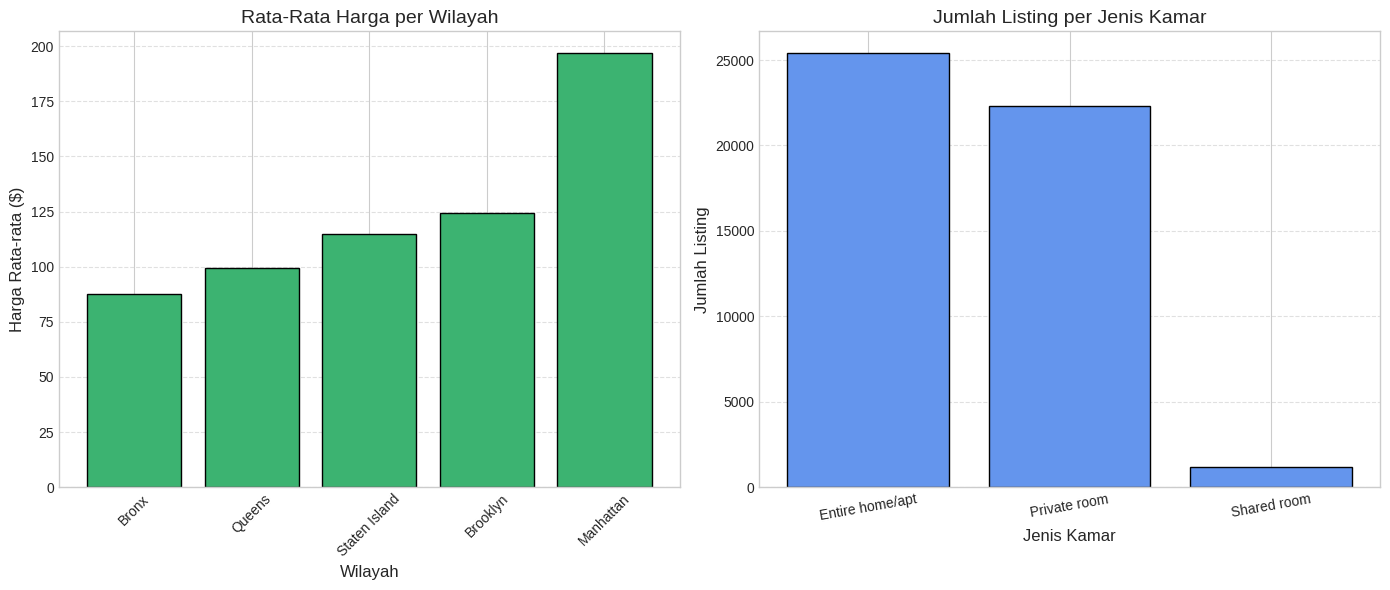

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

# Membaca data CSV Airbnb
df = pd.read_csv("airbnb.csv")

# Hitung rata-rata harga per wilayah
avg_price_per_area = df.groupby('neighbourhood_group')['price'].mean().sort_values()

# Hitung jumlah listing per jenis kamar
room_type_counts = df['room_type'].value_counts()

# ======== CETAK OUTPUT DATA =========
print("Rata-rata Harga per Wilayah:\n")
print(avg_price_per_area.round(2))
print("\nJumlah Listing per Jenis Kamar:\n")
print(room_type_counts)

# ======== VISUALISASI SUBPLOT =========
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Grafik 1: Bar chart rata-rata harga per wilayah
axes[0].bar(avg_price_per_area.index, avg_price_per_area.values,
            color='mediumseagreen', edgecolor='black')
axes[0].set_title('Rata-Rata Harga per Wilayah', fontsize=14)
axes[0].set_xlabel('Wilayah', fontsize=12)
axes[0].set_ylabel('Harga Rata-rata ($)', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', linestyle='--', alpha=0.6)

# Grafik 2: Bar chart jumlah listing per room_type
axes[1].bar(room_type_counts.index, room_type_counts.values,
            color='cornflowerblue', edgecolor='black')
axes[1].set_title('Jumlah Listing per Jenis Kamar', fontsize=14)
axes[1].set_xlabel('Jenis Kamar', fontsize=12)
axes[1].set_ylabel('Jumlah Listing', fontsize=12)
axes[1].tick_params(axis='x', rotation=10)
axes[1].grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


diagram

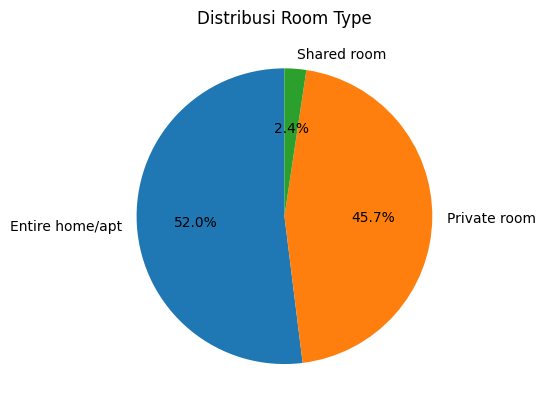

In [14]:
room_counts = df['room_type'].value_counts()
room_counts.plot.pie(autopct='%1.1f%%', startangle=90)
plt.title('Distribusi Room Type')
plt.ylabel('')
plt.show()

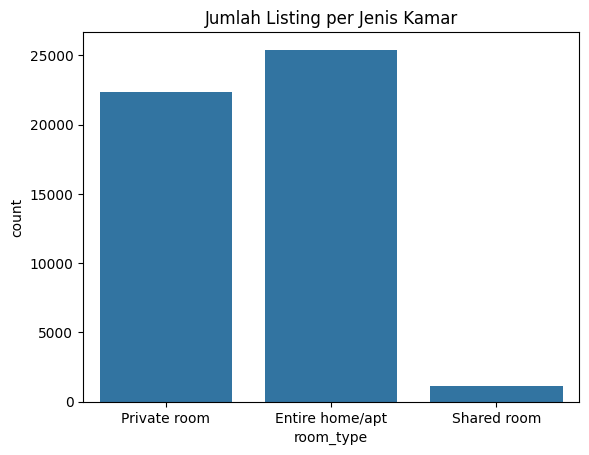

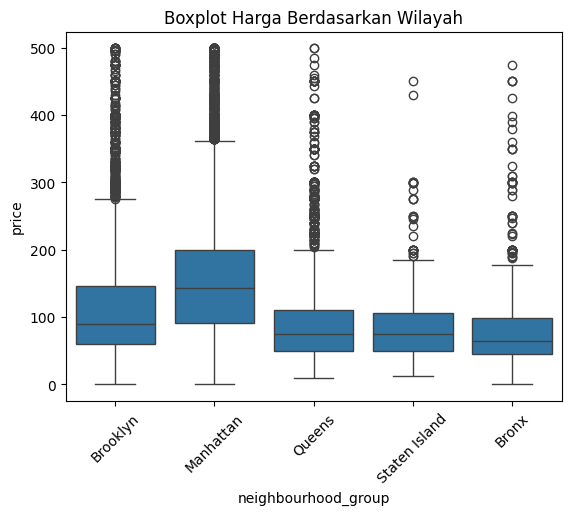

In [15]:
import seaborn as sns

# Countplot
sns.countplot(data=df, x='room_type')
plt.title("Jumlah Listing per Jenis Kamar")
plt.show()

# Boxplot harga berdasarkan wilayah
sns.boxplot(data=df[df['price'] < 500], x='neighbourhood_group', y='price')
plt.title("Boxplot Harga Berdasarkan Wilayah")
plt.xticks(rotation=45)
plt.show()

In [16]:
# Rata-rata harga per neighbourhood_group
avg_price = df.groupby('neighbourhood_group')['price'].mean()
print(avg_price)

# 5 host dengan jumlah listing terbanyak
top_hosts = df['host_id'].value_counts().head()
print(top_hosts)

# Wilayah dengan ketersediaan tertinggi
top_availability = df.groupby('neighbourhood')['availability_365'].mean().sort_values(ascending=False).head()
print(top_availability)

neighbourhood_group
Bronx             87.496792
Brooklyn         124.383207
Manhattan        196.875814
Queens            99.517649
Staten Island    114.812332
Name: price, dtype: float64
host_id
219517861    327
107434423    232
30283594     121
137358866    103
16098958      96
Name: count, dtype: int64
neighbourhood
Fort Wadsworth    365.000000
Co-op City        364.000000
Willowbrook       351.000000
Eastchester       333.461538
Richmondtown      300.000000
Name: availability_365, dtype: float64


BARU

BACASEMUA

In [26]:
import pandas as pd

# Baca dataset
df = pd.read_csv("airbnb.csv")

# Tampilkan info kolom dan jumlah missing value
df.info()
print("\nMissing Values:\n", df.isnull().sum())

# Statistik deskriptif dasar
print("\nDescriptive Statistics:\n", df.describe())

# Median kolom numerik
print("\nMedian Harga:", df['price'].median())

# Perbandingan harga minimum dan maksimum
min_price = df['price'].min()
max_price = df['price'].max()

print("Harga Minimum:", min_price)
print("Harga Maksimum:", max_price)

if min_price != 0:
    print("Rasio Max/Min:", max_price / min_price)
else:
    print("Rasio Max/Min: Tidak dapat dihitung (min = 0)")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [28]:
df = pd.read_csv("airbnb.csv")
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [29]:
price_series = df['price']

BARU LAGIIIIIIIIIII

Contoh data:
     id                                              name  host_id  \
0  2539                Clean & quiet apt home by the park     2787   
1  2595                             Skylit Midtown Castle     2845   
2  3647               THE VILLAGE OF HARLEM....NEW YORK !     4632   
3  3831                   Cozy Entire Floor of Brownstone     4869   
4  5022  Entire Apt: Spacious Studio/Loft by central park     7192   

     host_name neighbourhood_group neighbourhood  latitude  longitude  \
0         John            Brooklyn    Kensington  40.64749  -73.97237   
1     Jennifer           Manhattan       Midtown  40.75362  -73.98377   
2    Elisabeth           Manhattan        Harlem  40.80902  -73.94190   
3  LisaRoxanne            Brooklyn  Clinton Hill  40.68514  -73.95976   
4        Laura           Manhattan   East Harlem  40.79851  -73.94399   

         room_type  price  minimum_nights  number_of_reviews last_review  \
0     Private room    149               1          

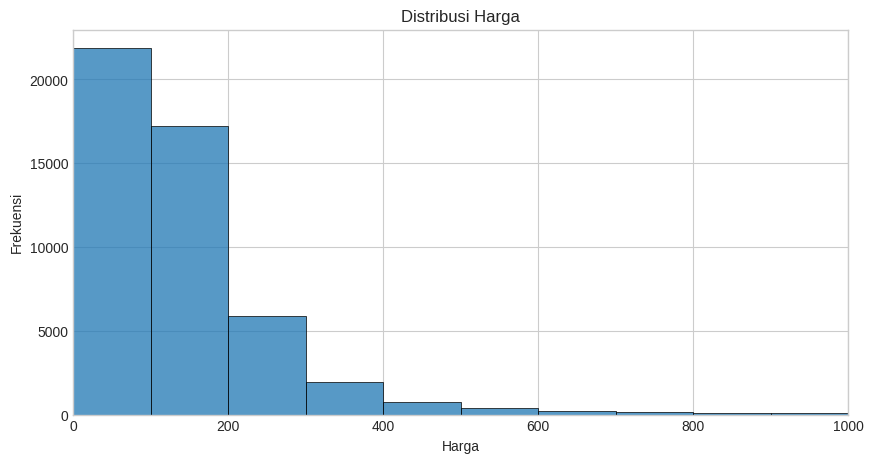

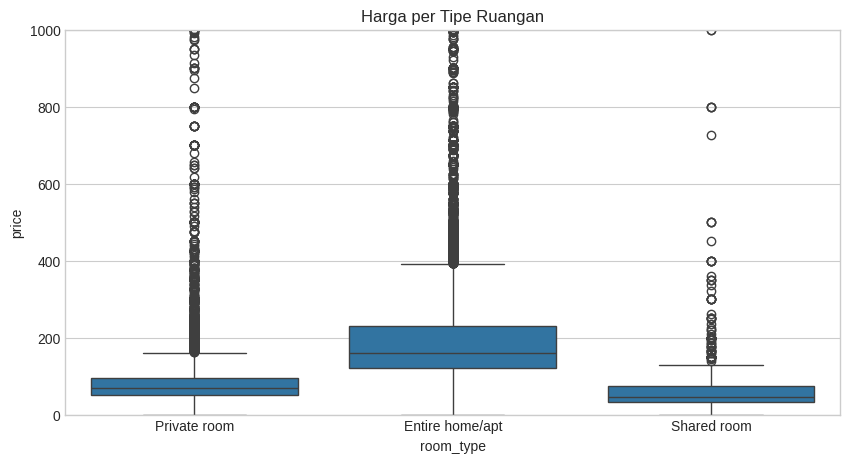

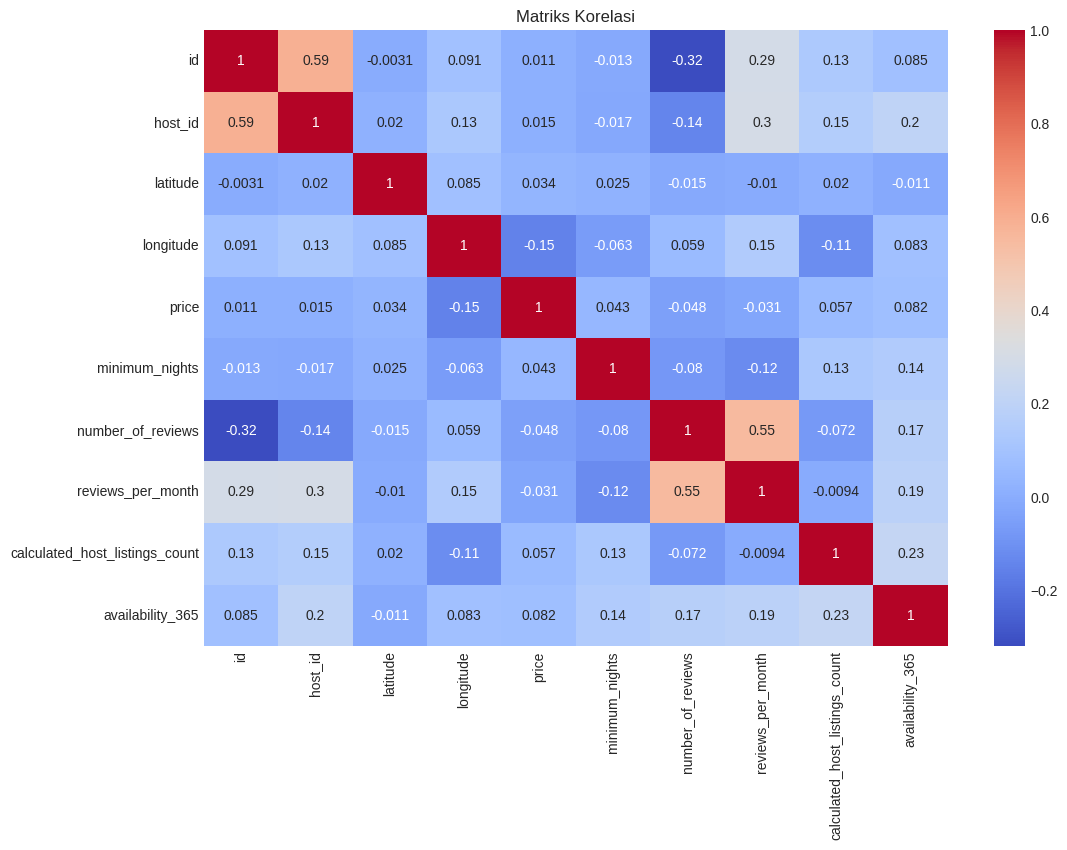

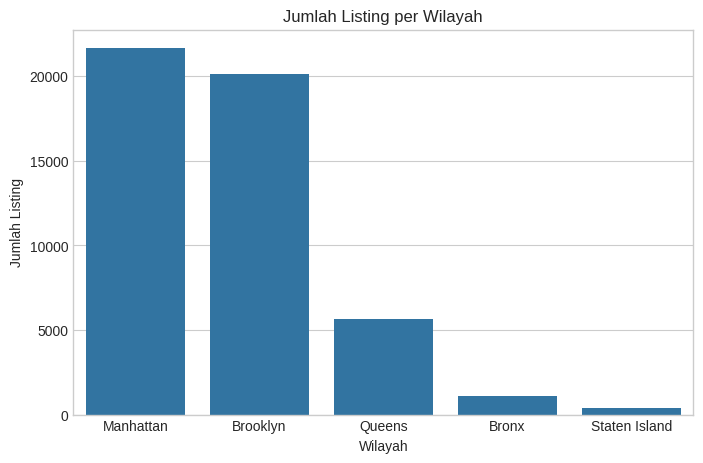

In [32]:
# 1. Import library yang dibutuhkan
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 3. Membaca file yang diupload
df = pd.read_csv("airbnb.csv")

# 4. Menampilkan 5 baris pertama
print("Contoh data:")
print(df.head())

# 5. Info struktur data
print("\nInformasi dataset:")
print(df.info())
df = pd.read_csv("airbnb.csv")
# 6. Statistik deskriptif
print("\nStatistik deskriptif:")
print(df.describe())

# 7. Cek missing value
print("\nJumlah missing value per kolom:")
print(df.isnull().sum())

# 8. Plot distribusi harga
plt.figure(figsize=(10,5))
sns.histplot(df['price'], bins=100, kde=False)
plt.title("Distribusi Harga")
plt.xlabel("Harga")
plt.ylabel("Frekuensi")
plt.xlim(0, 1000)  # batasi agar outlier tidak mendominasi
plt.show()

# 9. Boxplot harga berdasarkan jenis ruangan
plt.figure(figsize=(10,5))
sns.boxplot(x='room_type', y='price', data=df)
plt.title("Harga per Tipe Ruangan")
plt.ylim(0, 1000)
plt.show()

# 10. Korelasi antar fitur numerik
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Matriks Korelasi")
plt.show()

# 11. Distribusi listing per wilayah besar (neighbourhood_group)
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='neighbourhood_group', order=df['neighbourhood_group'].value_counts().index)
plt.title("Jumlah Listing per Wilayah")
plt.ylabel("Jumlah Listing")
plt.xlabel("Wilayah")
plt.show()


In [ ]:


df = pd.read_csv("airbnb.csv")

# 1.4 Menampilkan DataFrame
print(df.head())

# 1.5 Series: Mengakses satu kolom
print("\nContoh Series kolom 'price':")
print(df['price'].head())

# 1.6 Manipulasi DataFrame
df['price_per_night'] = df['price'] / df['minimum_nights']
df['price_per_night'] = df['price_per_night'].replace([float('inf'), float('nan')], 0)
print("\nKolom baru 'price_per_night' ditambahkan:")

# 1.7 Plotting menggunakan Pandas
df['room_type'].value_counts().plot(kind='bar', title='Jumlah Tiap Tipe Ruangan')
plt.ylabel("Jumlah")
plt.show()
